# Estudio de los datasets de Open X-Embodiment

## 1. Objetivos y  criterios de selección


## 2. Evaluación de TACO Play

### 2.1 Estructura y muestra real

In [ ]:
from datasets import load_dataset_builder

# Inicializar el constructor del dataset
builder = load_dataset_builder("lerobot/taco_play")

# Impresión de la información estructural
print("Dataset:", builder.name)
print("Versión:", builder.info.version)
print("\nCaracterísticas (Features):")
print(builder.info.features)

print("\nParticiones (Splits):")
print(builder.info.splits)

README.md:   0%|          | 0.00/4.77k [00:00<?, ?B/s]

c:\TFM_Codigo\TFM-VLA\.venv\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\OSCAR\.cache\huggingface\hub\datasets--lerobot--taco_play. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Dataset: parquet
Versión: 0.0.0

Características (Features):
{'observation.state': List(Value('float32')), 'action': List(Value('float32')), 'timestamp': Value('float32'), 'episode_index': Value('int64'), 'frame_index': Value('int64'), 'next.reward': Value('float32'), 'next.done': Value('bool'), 'index': Value('int64'), 'task_index': Value('int64')}

Particiones (Splits):
{'train': SplitInfo(name='train', num_bytes=25355215, num_examples=237798)}


In [ ]:
from huggingface_hub import snapshot_download

RUTA = r"E:\TFM_datasets\taco_play_lerobot"

snapshot_download(
    repo_id="lerobot/taco_play",
    repo_type="dataset",
    local_dir=RUTA,
    cache_dir=r"E:\TFM_datasets\hf_cache",
)

<>:4: SyntaxWarning: invalid escape sequence '\T'
<>:4: SyntaxWarning: invalid escape sequence '\T'
C:\Users\OSCAR\AppData\Local\Temp\ipykernel_6052\3255148338.py:4: SyntaxWarning: invalid escape sequence '\T'
  RUTA = r"E:\TFM_datasets\taco_play_lerobot"


'\nfrom huggingface_hub import snapshot_download\n\nRUTA = r"E:\\TFM_datasets\taco_play_lerobot"\n\nsnapshot_download(\n    repo_id="lerobot/taco_play",\n    repo_type="dataset",\n    local_dir=RUTA,\n    cache_dir=r"E:\\TFM_datasets\\hf_cache",\n)\n'

In [ ]:
from pathlib import Path
import json
import pandas as pd

RUTA = Path(r"E:\TFM_datasets\taco_play_lerobot")

# Metadatos generales
with open(RUTA / "meta" / "info.json", encoding="utf-8") as f:
    info = json.load(f)

print("Episodios:", info["total_episodes"])
print("Fotogramas:", info["total_frames"])
print("Tareas:", info["total_tasks"])
print("\nCampos disponibles:")
print(list(info["features"].keys()))

# Instrucciones de tarea
tareas = pd.read_parquet(RUTA / "meta" / "tasks.parquet")
display(tareas.head())

# Una muestra real de acciones y estado
archivo = sorted((RUTA / "data").rglob("*.parquet"))[0]
muestra = pd.read_parquet(archivo).head()

print("Archivo analizado:", archivo.name)
display(muestra)

Episodios: 3603
Fotogramas: 237798
Tareas: 406

Campos disponibles:
['observation.images.rgb_static', 'observation.images.rgb_gripper', 'observation.state', 'action', 'timestamp', 'episode_index', 'frame_index', 'next.reward', 'next.done', 'index', 'task_index']


,task_index
rotate the yellow block to the left,0
push right the yellow block,1
open the drawer,2
place the pink block on top of the purple block,3
turn off the blue led light,4


Archivo analizado: file-000.parquet


,observation.state,action,timestamp,episode_index,frame_index,next.reward,next.done,index,task_index
0,"[0.32943976, -0.048330203, 0.26344588, -3.0594...","[0.10251923, 0.104787074, -0.25172234, -0.0872...",0.000000,0,0,0.0,False,0,0
1,"[0.3293118, -0.048061445, 0.25973213, -3.04887...","[0.12426677, 0.044257797, -0.23885965, -0.2514...",0.066667,0,1,0.0,False,1,0
2,"[0.32957083, -0.046690024, 0.2545299, -3.04140...","[0.08845188, 0.02940148, -0.15476942, -0.28909...",0.133333,0,2,0.0,False,2,0
3,"[0.3304417, -0.045885127, 0.24830702, -3.03943...","[0.20840426, 0.054982908, -0.19856691, 0.05240...",0.200000,0,3,0.0,False,3,0
4,"[0.3316889, -0.0458334, 0.24149749, -3.0416894...","[0.26733512, 0.04810836, -0.096565485, -0.5325...",0.266667,0,4,0.0,False,4,0


In [6]:
fila = muestra.iloc[4]

id_tarea = int(fila["task_index"])
instruccion = tareas.index[
    tareas["task_index"] == id_tarea
][0]

print("Instrucción:", instruccion)
print("Estado: ", len(fila["observation.state"]), "valores")
print("Acción: ", len(fila["action"]), "valores")
print("Acción concreta:", fila["action"])
print("Episodio:", fila["episode_index"])
print("Fotograma:", fila["frame_index"])

Instrucción: rotate the yellow block to the left
Estado:  7 valores
Acción:  7 valores
Acción concreta: [ 0.26733512  0.04810836 -0.09656549 -0.5325335  -0.1830007   0.1995082
  1.        ]
Episodio: 0
Fotograma: 4


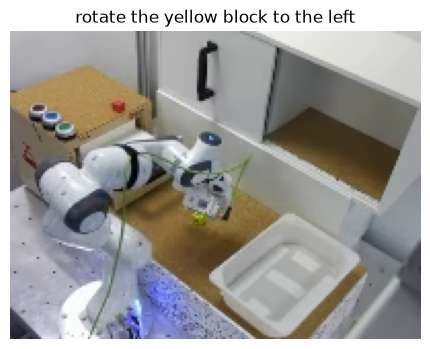

In [13]:
import cv2
import matplotlib.pyplot as plt

video = sorted(
    (RUTA / "videos" / "observation.images.rgb_static").rglob("*.mp4")
)[0]

captura = cv2.VideoCapture(str(video))
captura.set(cv2.CAP_PROP_POS_FRAMES, int(fila["frame_index"]))
ok, imagen = captura.read()
captura.release()

if ok:
    plt.figure(figsize=(6, 4))
    plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
    plt.title(instruccion)
    plt.axis("off")
    plt.show()
else:
    print("No se pudo leer el vídeo.")

### 2.2. Volumen y diversidad

Obtención del número de episodios, fotogramas e instrucciones.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

archivos = sorted((RUTA / "data").rglob("*.parquet"))

lista_episodios = []
for archivo in archivos:
    datos = pd.read_parquet(
        archivo,
        columns=["episode_index", "task_index"]
    )
    datos["archivo"] = archivo.name
    lista_episodios.append(
        datos.drop_duplicates(["archivo", "episode_index"])
    )

episodios = pd.concat(lista_episodios, ignore_index=True)

conteo = episodios["task_index"].value_counts()

print("Episodios analizados:", len(episodios))
print("Tareas diferentes:", len(conteo))
print("Mínimo:", conteo.min())
print("Máximo:", conteo.max())

Episodios analizados: 3603
Tareas diferentes: 406
Mínimo: 1
Máximo: 43


,Instrucción,Episodios
0,pick up the pink block,43
1,open the cabinet drawer,41
2,grasp the drawer handle and open it,41
3,pull the drawer,41
4,grasp the purple block,37
5,grasp the pink block,36
6,grasp the handle of the drawer and open it,36
7,lift the yellow block,36
8,go towards the purple block and grasp it,35
9,go open the drawer,35


,Instrucción,Episodios
396,store the pink object in the box,1
397,go push the yellow block into the drawer,1
398,push right the pink block,1
399,put the pink object inside the box,1
400,grasp the pink block and turn it left,1
401,sweep the pink block to the right,1
402,put the grasped pink block on top of the purpl...,1
403,store the grasped purple object in the box,1
404,place the purple block in the drawer,1
405,place the grasped yellow object inside the box,1


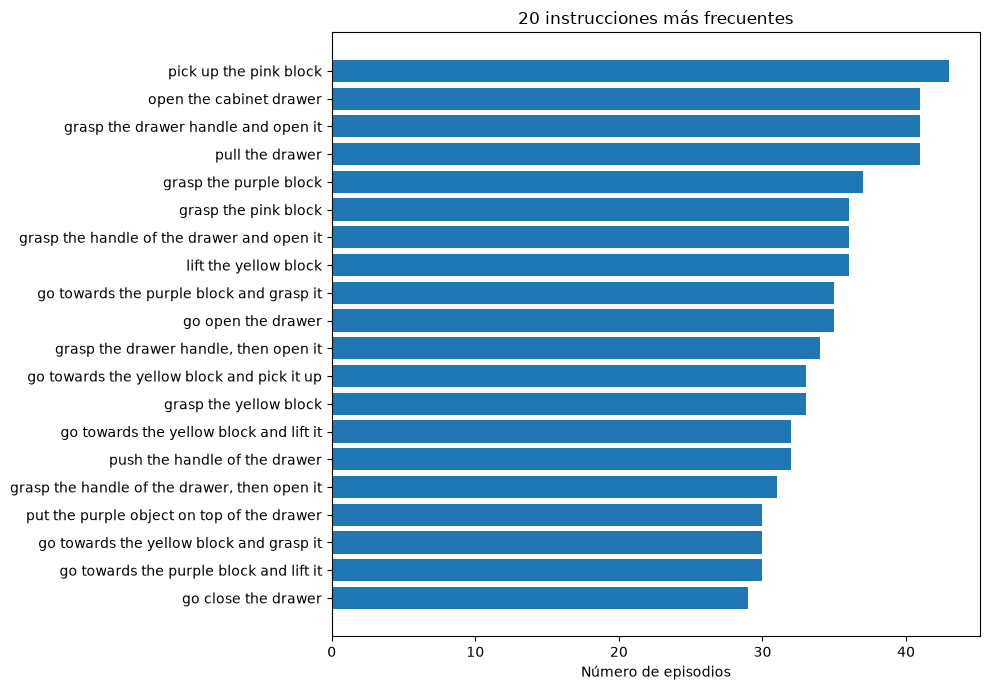

In [25]:
mapa_tareas = dict(zip(tareas["task_index"], tareas.index))

resumen = pd.DataFrame({
    "Instrucción": conteo.index.map(mapa_tareas),
    "Episodios": conteo.values
})

display(resumen.head(10))
display(resumen.tail(10))

plt.figure(figsize=(10, 7))
plt.barh(
    resumen.head(20)["Instrucción"][::-1],
    resumen.head(20)["Episodios"][::-1]
)
plt.xlabel("Número de episodios")
plt.title("20 instrucciones más frecuentes")
plt.tight_layout()
plt.show()

Obtención de la duración de los episodios.

In [26]:
FPS = 15
duraciones = []

for archivo in archivos:
    datos = pd.read_parquet(
        archivo,
        columns=["episode_index", "frame_index"]
    )

    datos["archivo"] = str(archivo.relative_to(RUTA))

    resumen_archivo = (
        datos.groupby(["archivo", "episode_index"])
        .size()
        .reset_index(name="fotogramas")
    )

    duraciones.append(resumen_archivo)

duraciones = pd.concat(duraciones, ignore_index=True)
duraciones["segundos"] = duraciones["fotogramas"] / FPS

print("Episodios:", len(duraciones))
print("Fotogramas totales:", duraciones["fotogramas"].sum())
print("Media:", round(duraciones["segundos"].mean(), 2), "s")
print("Mediana:", round(duraciones["segundos"].median(), 2), "s")
print("Mínimo:", round(duraciones["segundos"].min(), 2), "s")
print("Máximo:", round(duraciones["segundos"].max(), 2), "s")

Episodios: 3603
Fotogramas totales: 237798
Media: 4.4 s
Mediana: 4.4 s
Mínimo: 4.4 s
Máximo: 4.4 s


Evaluación de la diversidad semántica

,Formulaciones,Episodios
Categoría,,
Colocar,138,897
Coger/levantar,22,572
Encender/apagar,42,403
Apilar,38,364
Girar,65,278
Empujar,34,253
Mover,36,252
Abrir,7,245
Cerrar,7,176


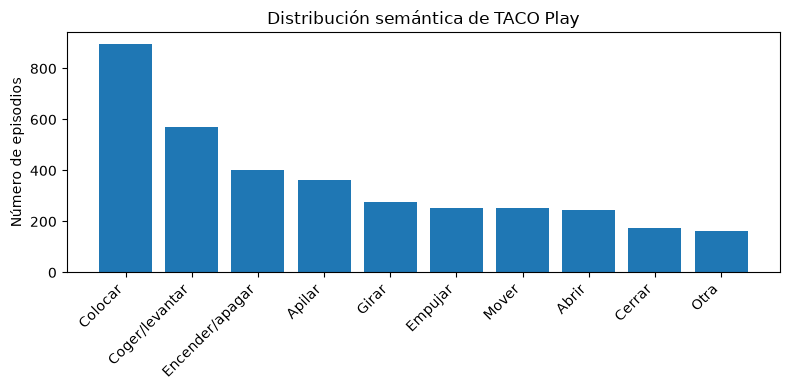

,Instrucción,Episodios
24,pull the drawer,41
28,pull the handle of the drawer,22
30,sweep the yellow block to the left,13
165,switch off the red light,12
187,take off the purple block,5
199,take off the pink block,1
206,switch off the blue light,22
261,switch off the green light,16
267,sweep the yellow block to the right,5
287,sweep the purple block to the right,3


In [ ]:
def categorizar(instruccion):
    texto = instruccion.lower()

    if "turn on" in texto or "turn off" in texto:
        return "Encender/apagar"
    elif "open" in texto:
        return "Abrir"
    elif "close" in texto:
        return "Cerrar"
    elif "rotate" in texto or "turn left" in texto or "turn right" in texto or "turn" in texto or "flip" in texto or "twist" in texto:
        return "Girar"
    elif "push" in texto:
        return "Empujar"
    elif "stack" in texto or "on top of" in texto:
        return "Apilar"
    elif "place" in texto or "put" in texto or "store" in texto:
        return "Colocar"
    elif "pick" in texto or "lift" in texto  or "grasp" in texto or "take" in texto:
        return "Coger/levantar"
    elif "move" in texto or "slide" in texto:
        return "Mover"
    else:
        return "Otra"

instrucciones = tareas.reset_index()
instrucciones.columns = ["Instrucción", "task_index"]

instrucciones["Categoría"] = instrucciones["Instrucción"].apply(categorizar)
instrucciones["Episodios"] = instrucciones["task_index"].map(conteo)

resumen_semantico = (
    instrucciones.groupby("Categoría")
    .agg(
        Formulaciones=("Instrucción", "count"),
        Episodios=("Episodios", "sum")
    )
    .sort_values("Episodios", ascending=False)
)

display(resumen_semantico)

plt.figure(figsize=(8, 4))
plt.bar(
    resumen_semantico.index,
    resumen_semantico["Episodios"]
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Número de episodios")
plt.title("Distribución semántica de TACO Play")
plt.tight_layout()
plt.show()

display(
    instrucciones[
        instrucciones["Categoría"] == "Otra"
    ][["Instrucción", "Episodios"]]
)


### 2.3. Acciones y calidad

Verificación de la dimensión y rangos de las acciones 7D.

In [38]:
import numpy as np
import pandas as pd

minimos = None
maximos = None
dimensiones = set()

for archivo in archivos:
    acciones = pd.read_parquet(
        archivo,
        columns=["action"]
    )["action"]

    matriz = np.vstack(acciones.to_numpy())

    dimensiones.add(matriz.shape[1])

    if minimos is None:
        minimos = matriz.min(axis=0)
        maximos = matriz.max(axis=0)
    else:
        minimos = np.minimum(minimos, matriz.min(axis=0))
        maximos = np.maximum(maximos, matriz.max(axis=0))

print("Dimensiones detectadas:", dimensiones)

rangos_accion = pd.DataFrame({
    "Dimensión de acción": [f"Acción {i}" for i in range(1, 8)],
    "Mínimo": minimos,
    "Máximo": maximos
})

display(rangos_accion)

Dimensiones detectadas: {7}


,Dimensión de acción,Mínimo,Máximo
0,Acción 1,-4.242458,1.491584
1,Acción 2,-3.192805,2.184243
2,Acción 3,-1.337147,2.683640
3,Acción 4,-4.202683,5.035227
4,Acción 5,-2.672264,2.665865
5,Acción 6,-3.346714,4.250769
6,Acción 7,0.000000,1.000000


Comprobación de valores ausentes o episodios defectuosos

In [39]:
import numpy as np

calidad = []

for archivo in archivos:
    datos = pd.read_parquet(
        archivo,
        columns=[
            "episode_index",
            "frame_index",
            "task_index",
            "observation.state",
            "action",
            "next.done",
        ]
    )

    datos["archivo"] = str(archivo.relative_to(RUTA))

    # Una fila es válida si estado y acción tienen 7 valores finitos
    datos["accion_valida"] = datos["action"].apply(
        lambda x: len(x) == 7 and np.isfinite(x).all()
    )

    datos["estado_valido"] = datos["observation.state"].apply(
        lambda x: len(x) == 7 and np.isfinite(x).all()
    )

    datos["metadatos_validos"] = (
        datos[["episode_index", "frame_index", "task_index"]]
        .notna()
        .all(axis=1)
    )

    datos["fila_invalida"] = ~(
        datos["accion_valida"]
        & datos["estado_valido"]
        & datos["metadatos_validos"]
    )

    resumen = (
        datos.groupby(["archivo", "episode_index"])
        .agg(
            fotogramas=("frame_index", "count"),
            fotogramas_unicos=("frame_index", "nunique"),
            finales=("next.done", "sum"),
            filas_invalidas=("fila_invalida", "sum"),
        )
        .reset_index()
    )

    calidad.append(resumen)

calidad = pd.concat(calidad, ignore_index=True)

calidad["defectuoso"] = (
    (calidad["fotogramas"] != 66)
    | (calidad["fotogramas_unicos"] != 66)
    | (calidad["finales"] != 1)
    | (calidad["filas_invalidas"] > 0)
)

problemas = calidad[calidad["defectuoso"]]

print("Episodios analizados:", len(calidad))
print("Episodios defectuosos:", len(problemas))

display(problemas.head(20))

Episodios analizados: 3603
Episodios defectuosos: 0


,archivo,episode_index,fotogramas,fotogramas_unicos,finales,filas_invalidas,defectuoso


## 3. Evaluación de Bridge

### 3.1. Estructura y muestra real

In [64]:
# Metadatos generales del dataset completo
with open(RUTA / "meta" / "info.json", encoding="utf-8") as f:
    info_bridge = json.load(f)

print("Episodios totales de Bridge V2:", info_bridge.get("total_episodes"))
print("Fotogramas totales:", info_bridge.get("total_frames"))
print("Tareas diferentes:", info_bridge.get("total_tasks"))
print("Frecuencia:", info_bridge.get("fps"), "FPS")

print("\nCampos disponibles:")
print(list(info_bridge["features"].keys()))

Episodios totales de Bridge V2: 50415
Fotogramas totales: 1801090
Tareas diferentes: 22199
Frecuencia: 5 FPS

Campos disponibles:
['observation.images.image_0', 'observation.images.image_1', 'observation.images.image_2', 'observation.images.image_3', 'observation.state', 'action', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index']


In [42]:
from huggingface_hub import snapshot_download

RUTA_BRIDGE = r"E:\TFM_datasets\bridge_subset"

PATRONES = [
    "meta/**",
    "data/chunk-000/file-000.parquet",
    "videos/observation.images.image_0/chunk-000/file-000.mp4",
]

snapshot_download(
    repo_id="nvidia/bridge_lerobot_v3",
    repo_type="dataset",
    local_dir=RUTA_BRIDGE,
    cache_dir=r"E:\TFM_datasets\hf_cache",
    allow_patterns=PATRONES,
    max_workers=2,
)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

'E:\\TFM_datasets\\bridge_subset'

In [73]:
RUTA_BRIDGE = Path(r"E:\TFM_datasets\bridge_subset")

# Metadatos generales
with open(RUTA_BRIDGE / "meta" / "info.json", encoding="utf-8") as f:
    info = json.load(f)

print("Episodios:", info["total_episodes"])
print("Fotogramas:", info["total_frames"])
print("Tareas:", info["total_tasks"])
print("\nCampos disponibles:")
print(list(info["features"].keys()))

# Instrucciones de tarea
tareas_bridge = pd.read_parquet(RUTA_BRIDGE / "meta" / "tasks.parquet")
display(tareas_bridge.head())

# Una muestra real de acciones y estado
archivo = sorted((RUTA_BRIDGE / "data").rglob("*.parquet"))[0]
muestra = pd.read_parquet(archivo).head()

print("Archivo analizado:", archivo.name)
display(muestra)

Episodios: 50415
Fotogramas: 1801090
Tareas: 22199

Campos disponibles:
['observation.images.image_0', 'observation.images.image_1', 'observation.images.image_2', 'observation.images.image_3', 'observation.state', 'action', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index']


,task_index
task,
flip cup upright,0
put cup from anywhere into sink,1
turn lever vertical to front,2
turn faucet left,3
pick up pot,4


Archivo analizado: file-000.parquet


,observation.state,action,timestamp,frame_index,episode_index,index,task_index
0,"[0.24604665, -0.04510668, 0.16955389, 0.030270...","[0.0, 6.938894e-18, -2.7755576e-17, -9.9227414...",0.0,0,0,0,0
1,"[0.24577253, -0.04543113, 0.1687788, 0.0325830...","[0.000253, 0.0011978, -0.011474, -0.0074642478...",0.2,1,0,1,0
2,"[0.24347913, -0.04600428, 0.15569289, 0.047507...","[0.00086801295, 0.001029405, -0.009284588, -0....",0.4,2,0,2,0
3,"[0.2437788, -0.046246376, 0.1484816, 0.0405189...","[0.00071611255, -0.00028564583, -0.011010776, ...",0.6,3,0,3,0
4,"[0.2444164, -0.046133276, 0.13712494, 0.037564...","[0.0010044264, -0.0018679332, -0.008475114, -0...",0.8,4,0,4,0


In [ ]:
fila = muestra.iloc[4]

id_tarea = int(fila["task_index"])
instruccion = tareas_bridge.index[
    tareas_bridge["task_index"] == id_tarea
][0]

print("Instrucción:", instruccion)
print("Estado: ", len(fila["observation.state"]), "valores")
print("Acción: ", len(fila["action"]), "valores")
print("Acción concreta:", fila["action"])
print("Episodio:", fila["episode_index"])
print("Fotograma:", fila["frame_index"])

Instrucción: flip cup upright
Estado:  7 valores
Acción:  7 valores
Acción concreta: [ 0.00100443 -0.00186793 -0.00847511 -0.00871195  0.00433175 -0.00384561
  1.        ]
Episodio: 0
Fotograma: 4


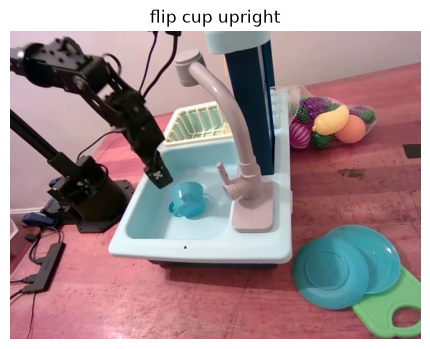

In [68]:
video = sorted(
    (RUTA_BRIDGE / "videos" / "observation.images.image_0" / "chunk-000").rglob("*.mp4")
)[0]

captura = cv2.VideoCapture(str(video))
captura.set(cv2.CAP_PROP_POS_FRAMES, int(fila["frame_index"]))
ok, imagen = captura.read()
captura.release()

if ok:
    plt.figure(figsize=(6, 4))
    plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
    plt.title(instruccion)
    plt.axis("off")
    plt.show()
else:
    print("No se pudo leer el vídeo.")

### 3.2. Volumen y diversidad

Obtención del número de episodios, fotogramas e instrucciones.

In [69]:
archivos_bridge = sorted((RUTA_BRIDGE / "data" / "chunk-000").rglob("*.parquet"))

resumen_episodios_bridge = []
for archivo in archivos_bridge:
    datos = pd.read_parquet(
        archivo,
        columns=["episode_index","frame_index", "task_index"]
    )
    datos["archivo"] = str(archivo.relative_to(RUTA_BRIDGE))
    lista_episodios.append(
        datos.drop_duplicates(["archivo", "episode_index"])
    )

    resumen = (
        datos.groupby(["archivo", "episode_index"])
        .agg(
            fotogramas=("frame_index", "count"),
            task_index=("task_index", "first"),
        )
        .reset_index()
    )

    resumen_episodios_bridge.append(resumen)

episodios_bridge = pd.concat(
    resumen_episodios_bridge,
    ignore_index=True
)

print("Episodios del subconjunto:", len(episodios_bridge))
print("Fotogramas del subconjunto:", episodios_bridge["fotogramas"].sum())
print(
    "Instrucciones diferentes en el subconjunto:",
    episodios_bridge["task_index"].nunique()
)

Episodios del subconjunto: 42056
Fotogramas del subconjunto: 1496285
Instrucciones diferentes en el subconjunto: 14775


,Instrucción,Episodios
0,,6608
1,sweep into pile,1092
2,turn lever vertical to front,586
3,open the drawer,484
4,close the drawer,418
5,put carrot on plate,379
6,open microwave,330
7,close microwave,330
8,flip pot upright in sink,305
9,open fridge,250


,Instrucción,Episodios
14765,Move the orange between the silver pot and the...,1
14766,Pick the pot and place it next to the blue brush,1
14767,Put the metal pot on the green cloth.,1
14768,Place the pot on the bottom left corner of the...,1
14769,Put the orange inside the pot.,1
14770,Pick up the orange item and place it on top of...,1
14771,Move the stainless steel pot and place it on t...,1
14772,put chocolate into bowl,1
14773,Put the bowl in front of the red can,1
14774,Place the chocolate to the left of the towel,1


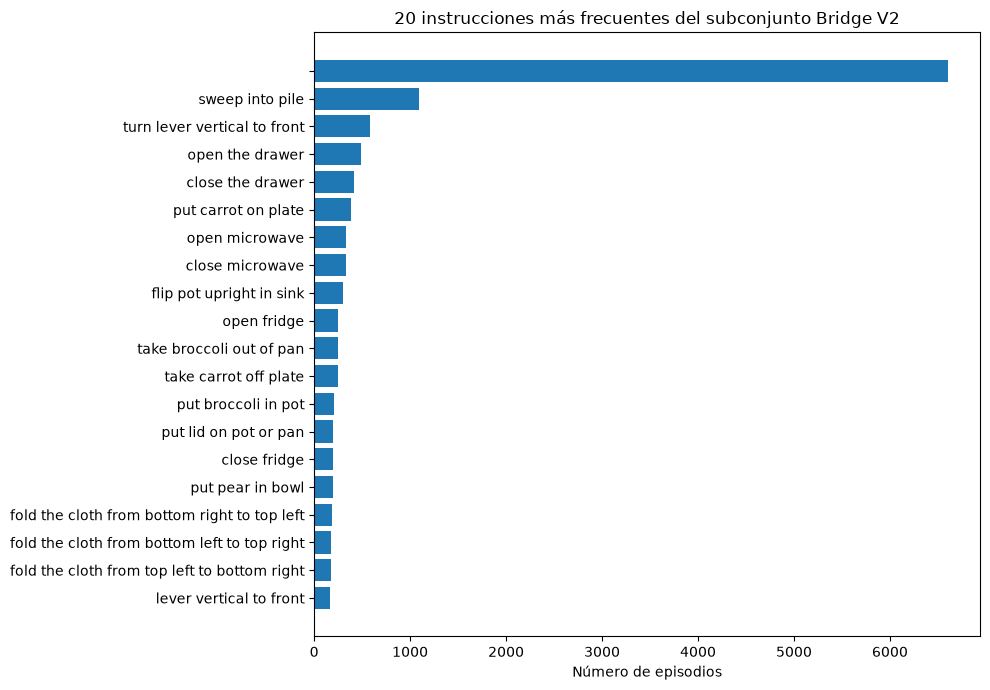

In [76]:
conteo_bridge = episodios_bridge["task_index"].value_counts()

if "task" in tareas_bridge.columns:
    texto_tareas_bridge = tareas_bridge["task"]
else:
    texto_tareas_bridge = tareas_bridge.index

mapa_tareas_bridge = dict(zip(
    tareas_bridge["task_index"],
    texto_tareas_bridge
))

resumen_bridge = pd.DataFrame({
    "Instrucción": conteo_bridge.index.map(mapa_tareas_bridge),
    "Episodios": conteo_bridge.values
})

display(resumen_bridge.head(10))
display(resumen_bridge.tail(10))

plt.figure(figsize=(10, 7))
plt.barh(
    resumen_bridge.head(20)["Instrucción"][::-1],
    resumen_bridge.head(20)["Episodios"][::-1]
)
plt.xlabel("Número de episodios")
plt.title("20 instrucciones más frecuentes del subconjunto Bridge V2")
plt.tight_layout()
plt.show()

In [ ]:
FPS = 5
duraciones = []

for archivo in archivos:
    datos = pd.read_parquet(
        archivo,
        columns=["episode_index", "frame_index"]
    )

    datos["archivo"] = str(archivo.relative_to(RUTA_BRIDGE))

    resumen_archivo = (
        datos.groupby(["archivo", "episode_index"])
        .size()
        .reset_index(name="fotogramas")
    )

    duraciones.append(resumen_archivo)

duraciones = pd.concat(duraciones, ignore_index=True)
duraciones["segundos"] = duraciones["fotogramas"] / FPS

print("Episodios:", len(duraciones))
print("Fotogramas totales:", duraciones["fotogramas"].sum())
print("Media:", round(duraciones["segundos"].mean(), 2), "s")
print("Mediana:", round(duraciones["segundos"].median(), 2), "s")
print("Mínimo:", round(duraciones["segundos"].min(), 2), "s")
print("Máximo:", round(duraciones["segundos"].max(), 2), "s")

Episodios: 42056
Fotogramas totales: 1496285
Media: 7.12 s
Mediana: 6.8 s
Mínimo: 1.4 s
Máximo: 23.8 s


Evaluación de la diversidad semántica

,Formulaciones,Episodios
Categoría,,
Otra,1833,13348.0
Colocar,7993,12180.0
Mover,9632,7059.0
Coger/levantar,582,2591.0
Abrir,152,1935.0
Cerrar,176,1738.0
Apilar,1646,1576.0
Girar,53,1504.0
Empujar,131,124.0


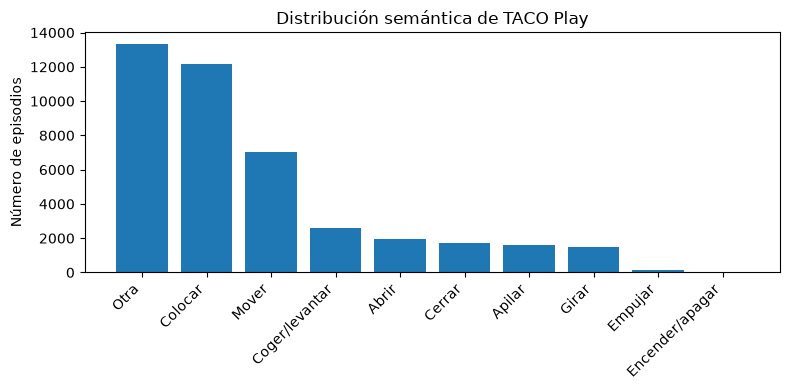

,Instrucción,Episodios
55,right pepper shaker,25.0
56,lever vertical to front,169.0
119,upright basil bottle cardboard fence,100.0
123,wipe pot with sponge,50.0
124,topple hot sauce bottle cardboard fence,50.0
...,...,...
21919,The red and blue spoons are separated.,NaN
21935,not moving anything,NaN
21949,moving the yellow cloth on the table from left...,NaN
21975,NOT MOVING ANITHING,NaN


In [77]:
def categorizar(instruccion):
    texto = instruccion.lower()

    if "turn on" in texto or "turn off" in texto:
        return "Encender/apagar"
    elif "open" in texto:
        return "Abrir"
    elif "close" in texto:
        return "Cerrar"
    elif "rotate" in texto or "turn left" in texto or "turn right" in texto or "turn" in texto or "flip" in texto or "twist" in texto:
        return "Girar"
    elif "push" in texto:
        return "Empujar"
    elif "stack" in texto or "on top of" in texto:
        return "Apilar"
    elif "place" in texto or "put" in texto or "store" in texto:
        return "Colocar"
    elif "pick" in texto or "lift" in texto  or "grasp" in texto or "take" in texto:
        return "Coger/levantar"
    elif "move" in texto or "slide" in texto:
        return "Mover"
    else:
        return "Otra"

instrucciones = tareas.reset_index()
instrucciones.columns = ["Instrucción", "task_index"]

instrucciones["Categoría"] = instrucciones["Instrucción"].apply(categorizar)
instrucciones["Episodios"] = instrucciones["task_index"].map(conteo)

resumen_semantico = (
    instrucciones.groupby("Categoría")
    .agg(
        Formulaciones=("Instrucción", "count"),
        Episodios=("Episodios", "sum")
    )
    .sort_values("Episodios", ascending=False)
)

display(resumen_semantico)

plt.figure(figsize=(8, 4))
plt.bar(
    resumen_semantico.index,
    resumen_semantico["Episodios"]
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Número de episodios")
plt.title("Distribución semántica de TACO Play")
plt.tight_layout()
plt.show()

display(
    instrucciones[
        instrucciones["Categoría"] == "Otra"
    ][["Instrucción", "Episodios"]]
)


### 3.3. Acciones y calidad

Verificación de la dimensión y rangos de las acciones 7D.

In [78]:
minimos = None
maximos = None
dimensiones = set()

for archivo in archivos:
    acciones = pd.read_parquet(
        archivo,
        columns=["action"]
    )["action"]

    matriz = np.vstack(acciones.to_numpy())

    dimensiones.add(matriz.shape[1])

    if minimos is None:
        minimos = matriz.min(axis=0)
        maximos = matriz.max(axis=0)
    else:
        minimos = np.minimum(minimos, matriz.min(axis=0))
        maximos = np.maximum(maximos, matriz.max(axis=0))

print("Dimensiones detectadas:", dimensiones)

rangos_accion = pd.DataFrame({
    "Dimensión de acción": [f"Acción {i}" for i in range(1, 8)],
    "Mínimo": minimos,
    "Máximo": maximos
})

display(rangos_accion)

Dimensiones detectadas: {7}


,Dimensión de acción,Mínimo,Máximo
0,Acción 1,-0.179106,0.144689
1,Acción 2,-0.221614,0.288960
2,Acción 3,-0.467002,0.250668
3,Acción 4,-0.905363,0.911026
4,Acción 5,-0.728706,0.676065
5,Acción 6,-1.161014,1.101324
6,Acción 7,0.000000,1.000000


Comprobación de valores ausentes o episodios defectuosos

In [79]:
def vector_valido(vector):
    try:
        vector = np.asarray(vector, dtype=float)
        return vector.shape == (7,) and np.isfinite(vector).all()
    except Exception:
        return False

calidad_bridge = []

for archivo in archivos:
    datos = pd.read_parquet(
        archivo,
        columns=[
            "episode_index",
            "frame_index",
            "task_index",
            "observation.state",
            "action",
        ]
    )

    datos["archivo"] = str(archivo.relative_to(RUTA_BRIDGE))

    datos["accion_valida"] = datos["action"].apply(vector_valido)
    datos["estado_valido"] = datos["observation.state"].apply(vector_valido)

    datos["metadatos_validos"] = (
        datos[["episode_index", "frame_index", "task_index"]]
        .notna()
        .all(axis=1)
    )

    datos["fila_invalida"] = ~(
        datos["accion_valida"]
        & datos["estado_valido"]
        & datos["metadatos_validos"]
    )

    resumen = (
        datos.groupby(["archivo", "episode_index"])
        .agg(
            fotogramas=("frame_index", "count"),
            fotogramas_unicos=("frame_index", "nunique"),
            primer_fotograma=("frame_index", "min"),
            ultimo_fotograma=("frame_index", "max"),
            filas_invalidas=("fila_invalida", "sum"),
        )
        .reset_index()
    )

    calidad_bridge.append(resumen)

calidad_bridge = pd.concat(calidad_bridge, ignore_index=True)

calidad_bridge["defectuoso"] = (
    (calidad_bridge["fotogramas"] < 2)
    | (calidad_bridge["fotogramas"] != calidad_bridge["fotogramas_unicos"])
    | (calidad_bridge["primer_fotograma"] != 0)
    | (calidad_bridge["ultimo_fotograma"] != calidad_bridge["fotogramas"] - 1)
    | (calidad_bridge["filas_invalidas"] > 0)
)

problemas_bridge = calidad_bridge[calidad_bridge["defectuoso"]]

print("Episodios analizados:", len(calidad_bridge))
print("Episodios defectuosos:", len(problemas_bridge))

display(problemas_bridge.head(20))

Episodios analizados: 42056
Episodios defectuosos: 0


,archivo,episode_index,fotogramas,fotogramas_unicos,primer_fotograma,ultimo_fotograma,filas_invalidas,defectuoso
